**2. MOCO TRAINING**

In [1]:
import digitalhub as dh
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_NAME = "floods"
project = dh.get_project(PROJECT_NAME)
print(f"Project: {project.name}")

Project: floods


**SETUP PARAMETERS**

In [2]:
job_name = "net_v3"                                     
dataset = "Standard"                                                                       
weights_encoder_sar = "autoencoder_2D_SAR_weights_convLstm_v1"     
weights_encoder_opt = "autoencoder_2D_OPT_weights_convLstm_v1"
                                        

parameters = {
    "job_name": job_name,
    "dataset": dataset,
    "weights_encoder_sar": weights_encoder_sar,
    "weights_encoder_opt": weights_encoder_opt,
    "resume": False, 
    "lr_min": 0.0003,   
    "cosine": False,  
    "simple_proj": False,
    "pool_grid": 4,
    "attn": False,
    "time_debug": False,   

    "epochs": 40, 
    "batch_size": 16,
    "lr": 0.005,
    "weight_decay": 1e-4,
    "momentum": 0.9,
    "patch_size": 256,
    "n_images1": 4, "n_channels1": 2,              
    "n_images2": 4, "n_channels2": 10,              
    "moco_dim": 128,
    "moco_k": 4096,                                     
    "moco_t": 0.07,
    "hidden_channels_dim": 64,
    "symmetric": False,
    "workers": 0,
    "patience": 40,
    "min_delta": 1e-4,                                   
}

volumes = [
    {
        "volume_type": "ephemeral",
        "name": "volume-spazio-dati",
        "mount_path": "/data",      
        "spec": {"size": "500Gi"}   
    }
]

**BUILD ENVIRONMENT**

In [ ]:
moco_2D_train_func = project.new_function(
    name= f'moco_2D_{job_name}',
    kind="python",
    python_version="PYTHON3_10",
    code_src="../src/", 
    handler="train_moco_2D", 
    base_image="pytorch/pytorch:2.1.2-cuda11.8-cudnn8-runtime",
    requirements=["pandas==2.3.3", "numpy==1.26.4", "rasterio==1.4.4", "tqdm==4.70.0", "tifffile==2024.8.30", "torch==2.1.2", "matplotlib==3.10.9", "digitalhub==0.15.11", "digitalhub-runtime-python==0.15.2", "zarr==2.18.0", "numcodecs==0.13.1", "xarray==2025.6.1"]
)

build = moco_2D_train_func.run("build", wait=True)
print(f"BUILD: {build.status.state}")

2026-09-28 20:22:48,489 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run f7295b2f6a4b4f10b339839ae64f4fad to finish...
2026-09-28 20:22:53,495 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run f7295b2f6a4b4f10b339839ae64f4fad to finish...
2026-09-28 20:22:58,503 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run f7295b2f6a4b4f10b339839ae64f4fad to finish...
2026-09-28 20:23:03,512 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run f7295b2f6a4b4f10b339839ae64f4fad to finish...
2026-09-28 20:23:08,521 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run f7295b2f6a4b4f10b339839ae64f4fad to finish...
2026-09-28 20:23:13,530 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run f7295b2f6a4b4f10b339839ae64f4fad to finish...
2026-09-28 20:23:18,539 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run f7295b2f6a4b4f10b339839ae64f4fad to finish...
2026-09-28 20

BUILD: COMPLETED


**TRAINING**

In [ ]:
run_moco_2D = moco_2D_train_func.run(
    action="job", 
    parameters=parameters, 
    volumes=volumes, 
    profile="1xv100-shared",
    local_execution= False,                       
    wait=True
)

print(f"Run moco avviato: {run_moco_2D.id}")

2026-09-28 20:23:43,796 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run ce936071c38b4a76907e9de7411f706c to finish...


2026-09-28 20:23:48,802 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run ce936071c38b4a76907e9de7411f706c to finish...
2026-09-28 20:23:53,811 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run ce936071c38b4a76907e9de7411f706c to finish...
2026-09-28 20:23:58,821 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run ce936071c38b4a76907e9de7411f706c to finish...
2026-09-28 20:24:03,830 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run ce936071c38b4a76907e9de7411f706c to finish...
2026-09-28 20:24:08,839 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run ce936071c38b4a76907e9de7411f706c to finish...
2026-09-28 20:24:13,848 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run ce936071c38b4a76907e9de7411f706c to finish...
2026-09-28 20:24:18,888 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run ce936071c38b4a76907e9de7411f706c to finish...
2026-09-28 20

**PLOTS**

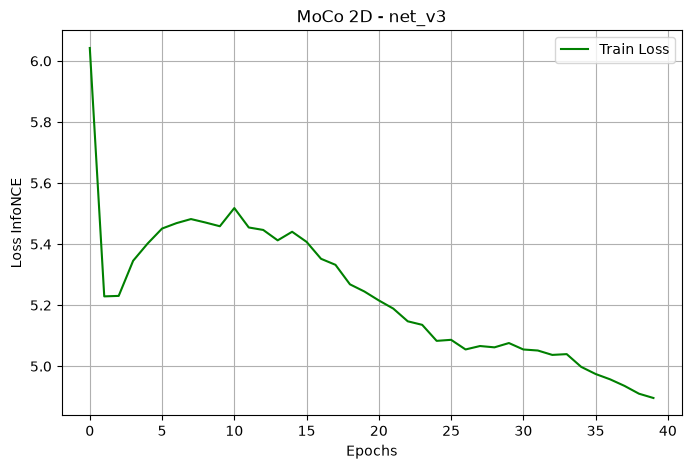

In [3]:
path = project.get_artifact(f"moco_2D_metrics_{job_name}").download(overwrite=True)
df = pd.read_csv(path)

plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], df['train_loss'], color='green', label='Train Loss')
plt.title(f'MoCo 2D - {job_name}')
plt.xlabel('Epochs')
plt.ylabel('Loss InfoNCE')
plt.grid(True)
plt.legend()
plt.show()